In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
results_df = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_kunbind_HPC.csv.gz", compression='gzip')

In [3]:
summary = (
    results_df
    .groupby('k_unbind')
    .agg(
        mean_kills=('kills', 'mean'),
        std_kills=('kills', 'std'),
        mean_contacts=('contacts', 'mean'),
        std_contacts=('contacts', 'std'),
        mean_synapses=('synapses', 'mean'),
        std_synapses=('synapses', 'std'),
    )
    .reset_index()
)
summary

,k_unbind,mean_kills,std_kills,mean_contacts,std_contacts,mean_synapses,std_synapses
0,0.01,28.7,2.213594,3756.9,343.094561,67.4,6.619836
1,0.03,28.9,5.363457,3829.1,648.555052,64.1,9.243015
2,0.10,29.9,5.087021,3884.2,586.961820,68.5,9.652288
3,0.30,26.7,3.560587,3604.1,399.271406,72.0,5.696002
4,0.50,25.9,3.725289,3671.4,488.934942,77.8,12.585706
5,1.00,21.5,2.758824,3340.6,472.550103,83.4,10.308572
6,2.00,13.6,4.427189,2979.1,569.213385,97.8,14.397531
7,3.00,10.2,2.149935,2608.9,261.875904,104.7,9.855061
8,5.00,4.6,2.065591,2029.3,348.206851,109.1,20.851059
9,10.00,0.4,0.516398,1551.6,192.064920,131.1,16.722905


In [5]:
results_df.head(10)

,k_unbind,seed,kills,contacts,synapses
0,0.01,1,29,4093,78
1,0.01,2,27,3913,69
2,0.01,3,32,3900,68
3,0.01,4,31,3872,67
4,0.01,5,29,4257,65
5,0.01,6,25,3812,73
6,0.01,7,29,3785,73
7,0.01,8,27,3354,63
8,0.01,9,27,3431,64
9,0.01,10,31,3152,54


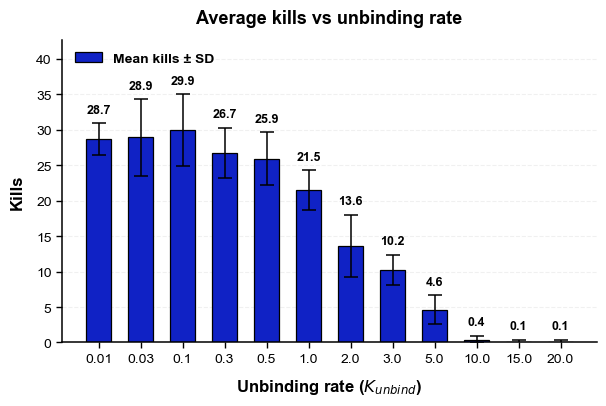

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(summary))

bar_color = "#1022C5"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(6.2, 4.2), facecolor="none")
ax.set_facecolor("none")

bars = ax.bar(
    x,
    summary["mean_kills"],
    yerr=summary["std_kills"],
    capsize=5,
    color=bar_color,
    edgecolor="black",
    linewidth=0.9,
    width=0.58,
    error_kw=dict(
        lw=1.1,
        capthick=1.1,
        ecolor="black",
    ),
    label="Mean kills ± SD",
)

y_max = max(summary["mean_kills"] + summary["std_kills"]) * 1.22
ax.set_ylim(0, y_max)

ax.set_xticks(x)
ax.set_xticklabels(summary["k_unbind"])
ax.set_xlabel("Unbinding rate ($K_{unbind}$)", fontweight="bold", labelpad=8)
ax.set_ylabel("Kills", fontweight="bold", labelpad=8)
ax.set_title("Average kills vs unbinding rate", fontweight="bold", pad=12)

offset = y_max * 0.025

for i, bar in enumerate(bars):
    height = bar.get_height()
    err = summary["std_kills"].iloc[i] if hasattr(summary["std_kills"], "iloc") else summary["std_kills"][i]

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + err + offset,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

legend = ax.legend(
    frameon=False,
    loc="upper left",
)

for text in legend.get_texts():
    text.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.tick_params(axis="both", width=1.0, length=4)

ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("3.2_kunbindsweep_kills.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

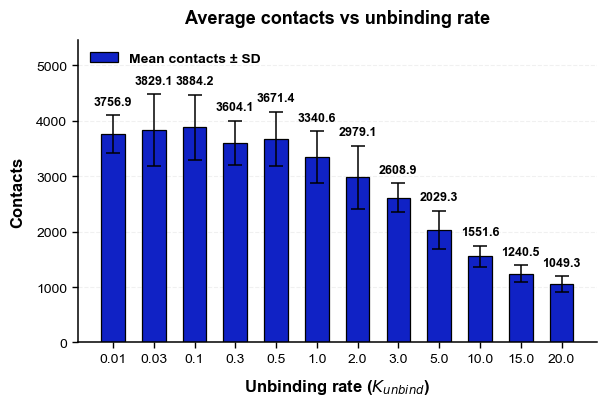

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(summary))

bar_color = "#1022C5"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(6.2, 4.2), facecolor="none")
ax.set_facecolor("none")

bars = ax.bar(
    x,
    summary["mean_contacts"],
    yerr=summary["std_contacts"],
    capsize=5,
    color=bar_color,
    edgecolor="black",
    linewidth=0.9,
    width=0.58,
    error_kw=dict(
        lw=1.1,
        capthick=1.1,
        ecolor="black",
    ),
    label="Mean contacts ± SD",
)

y_max = max(summary["mean_contacts"] + summary["std_contacts"]) * 1.22
ax.set_ylim(0, y_max)

ax.set_xticks(x)
ax.set_xticklabels(summary["k_unbind"])
ax.set_xlabel("Unbinding rate ($K_{unbind}$)", fontweight="bold", labelpad=8)
ax.set_ylabel("Contacts", fontweight="bold", labelpad=8)
ax.set_title("Average contacts vs unbinding rate", fontweight="bold", pad=12)

offset = y_max * 0.025

for i, bar in enumerate(bars):
    height = bar.get_height()
    err = summary["std_contacts"].iloc[i] if hasattr(summary["std_contacts"], "iloc") else summary["std_contacts"][i]

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + err + offset,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

legend = ax.legend(frameon=False, loc="upper left")
for text in legend.get_texts():
    text.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.tick_params(axis="both", width=1.0, length=4)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("3.2_kunbindsweep_contacts.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

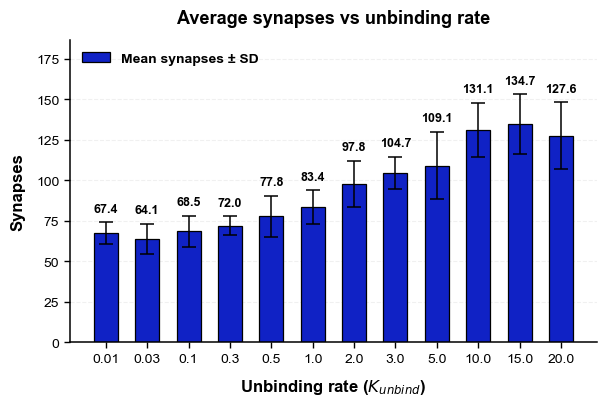

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(summary))

bar_color = "#1022C5"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

fig, ax = plt.subplots(figsize=(6.2, 4.2), facecolor="none")
ax.set_facecolor("none")

bars = ax.bar(
    x,
    summary["mean_synapses"],
    yerr=summary["std_synapses"],
    capsize=5,
    color=bar_color,
    edgecolor="black",
    linewidth=0.9,
    width=0.58,
    error_kw=dict(
        lw=1.1,
        capthick=1.1,
        ecolor="black",
    ),
    label="Mean synapses ± SD",
)

y_max = max(summary["mean_synapses"] + summary["std_synapses"]) * 1.22
ax.set_ylim(0, y_max)

ax.set_xticks(x)
ax.set_xticklabels(summary["k_unbind"])
ax.set_xlabel("Unbinding rate ($K_{unbind}$)", fontweight="bold", labelpad=8)
ax.set_ylabel("Synapses", fontweight="bold", labelpad=8)
ax.set_title("Average synapses vs unbinding rate", fontweight="bold", pad=12)

offset = y_max * 0.025

for i, bar in enumerate(bars):
    height = bar.get_height()
    err = summary["std_synapses"].iloc[i] if hasattr(summary["std_synapses"], "iloc") else summary["std_synapses"][i]

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + err + offset,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

legend = ax.legend(frameon=False, loc="upper left")
for text in legend.get_texts():
    text.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.tick_params(axis="both", width=1.0, length=4)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("3.2_kunbindsweep_synapses.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ratio_df = results_df.copy()

ratio_df["kills_per_synapse"] = np.where(
    ratio_df["synapses"] >= 0,
    ratio_df["kills"] / ratio_df["synapses"],
    np.nan
)

ratio_summary = (
    ratio_df
    .groupby("k_unbind", as_index=False)
    .agg(
        mean_efficiency=("kills_per_synapse", "mean"),
        std_efficiency=("kills_per_synapse", "std"),
        n=("kills_per_synapse", "count")
    )
)

ratio_summary["sem_efficiency"] = ratio_summary["std_efficiency"] / np.sqrt(ratio_summary["n"])

ratio_summary

,k_unbind,mean_efficiency,std_efficiency,n,sem_efficiency
0,0.01,0.430677,0.064478,10,0.020390
1,0.03,0.450391,0.047843,10,0.015129
2,0.10,0.438674,0.060170,10,0.019027
3,0.30,0.371454,0.045172,10,0.014285
4,0.50,0.338938,0.061152,10,0.019338
5,1.00,0.259592,0.034021,10,0.010758
6,2.00,0.137702,0.036377,10,0.011503
7,3.00,0.097148,0.016073,10,0.005083
8,5.00,0.044584,0.022126,10,0.006997
9,10.00,0.003260,0.004278,10,0.001353


    k_unbind  mean_ratio  std_ratio   n  sem_ratio
0       0.01   55.910713   4.196316  10   1.326992
1       0.03   59.700756   4.979640  10   1.574700
2       0.10   56.662327   2.834360  10   0.896303
3       0.30   50.048560   3.710220  10   1.173274
4       0.50   47.576144   4.451041  10   1.407543
5       1.00   40.051018   2.487989  10   0.786771
6       2.00   30.380035   3.351073  10   1.059702
7       3.00   24.989357   2.121258  10   0.670801
8       5.00   18.712452   1.453598  10   0.459668
9      10.00   11.853708   0.520783  10   0.164686
10     15.00    9.234267   0.512469  10   0.162057
11     20.00    8.267727   0.614578  10   0.194346


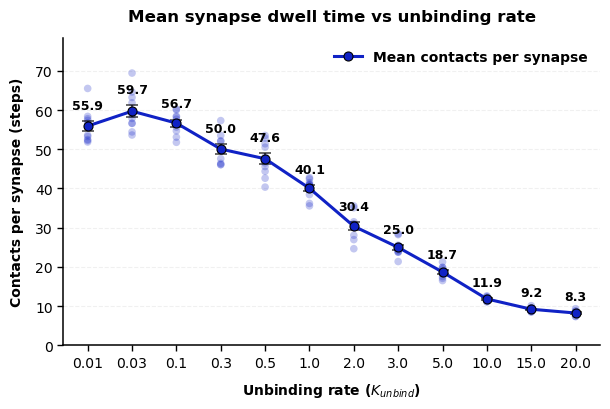

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

duration_df = results_df.copy()

duration_df["contacts_per_synapse"] = np.where(
    duration_df["synapses"] > 0,
    duration_df["contacts"] / duration_df["synapses"],
    np.nan  # exclude zero-synapse runs from average
)

summary_ratio = (
    duration_df
    .groupby("k_unbind", as_index=False)
    .agg(
        mean_ratio=("contacts_per_synapse", "mean"),
        std_ratio=("contacts_per_synapse",  "std"),
        n=("contacts_per_synapse",          "count"),
    )
)
summary_ratio["sem_ratio"] = summary_ratio["std_ratio"] / np.sqrt(summary_ratio["n"])

print(summary_ratio)

x = np.arange(len(summary_ratio))

fig, ax = plt.subplots(figsize=(6.2, 4.2), facecolor="none")
ax.set_facecolor("none")

for i, k in enumerate(summary_ratio["k_unbind"]):
    vals = duration_df.loc[
        duration_df["k_unbind"] == k,
        "contacts_per_synapse"
    ].dropna()
    ax.scatter(
        np.full(len(vals), i), vals,
        color="#1022C5", alpha=0.25, s=30,
        edgecolor="none", zorder=2,
    )


ax.plot(
    x,
    summary_ratio["mean_ratio"],
    marker="o", linewidth=2.2, markersize=6.5,
    color="#1022C5",
    markeredgecolor="black", markeredgewidth=0.8,
    label="Mean contacts per synapse",
    zorder=3,
)

ax.errorbar(
    x,
    summary_ratio["mean_ratio"],
    yerr=summary_ratio["sem_ratio"],
    fmt="none", capsize=4,
    elinewidth=1.1, capthick=1.1,
    color="black", alpha=0.75, zorder=2,
)


y_max = (summary_ratio["mean_ratio"] + summary_ratio["sem_ratio"]).max() * 1.28
ax.set_ylim(0, y_max)

for i, (val, err) in enumerate(zip(summary_ratio["mean_ratio"], summary_ratio["sem_ratio"])):
    if np.isfinite(val):
        ax.text(i, val + err + y_max * 0.03,
                f"{val:.1f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(summary_ratio["k_unbind"])
ax.set_xlabel("Unbinding rate ($K_{unbind}$)", fontweight="bold", labelpad=8)
ax.set_ylabel("Contacts per synapse (steps)", fontweight="bold", labelpad=8)
ax.set_title("Mean synapse dwell time vs unbinding rate", fontweight="bold", pad=12)

legend = ax.legend(frameon=False, loc="upper right")
for t in legend.get_texts():
    t.set_fontweight("bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)
ax.tick_params(axis="both", width=1.0, length=4)
ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("contacts_per_synapse_unbind.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()

    k_unbind  total_kills  total_synapses  mean_seed_efficiency  \
0       0.01          287             674              0.430677   
1       0.03          289             641              0.450391   
2       0.10          299             685              0.438674   
3       0.30          267             720              0.371454   
4       0.50          259             778              0.338938   
5       1.00          215             834              0.259592   
6       2.00          136             978              0.137702   
7       3.00          102            1047              0.097148   
8       5.00           46            1091              0.044584   
9      10.00            4            1311              0.003260   
10     15.00            1            1347              0.000741   
11     20.00            1            1276              0.000820   

    std_seed_efficiency  n_valid  aggregated_efficiency  sem_seed_efficiency  
0              0.064478       10               0.

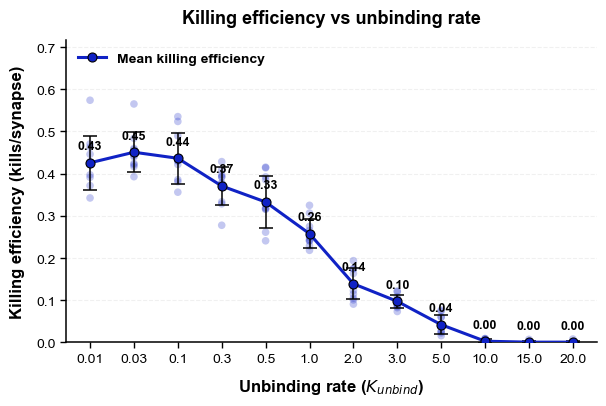

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

main_colour = "#1022C5"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

eff_df = results_df.copy()


eff_df["killing_efficiency"] = np.where(
    eff_df["synapses"] > 0,
    eff_df["kills"] / eff_df["synapses"],
    np.nan
)

eff_summary = (
    eff_df
    .groupby("k_unbind", as_index=False)
    .agg(
        total_kills=("kills", "sum"),
        total_synapses=("synapses", "sum"),
        mean_seed_efficiency=("killing_efficiency", "mean"),
        std_seed_efficiency=("killing_efficiency", "std"),
        n_valid=("killing_efficiency", "count"),
    )
)

eff_summary["aggregated_efficiency"] = np.where(
    eff_summary["total_synapses"] > 0,
    eff_summary["total_kills"] / eff_summary["total_synapses"],
    np.nan
)


eff_summary["sem_seed_efficiency"] = (
    eff_summary["std_seed_efficiency"] / np.sqrt(eff_summary["n_valid"])
)

print(eff_summary)

x = np.arange(len(eff_summary))

fig, ax = plt.subplots(figsize=(6.2, 4.2), facecolor="white")
ax.set_facecolor("white")


for i, k in enumerate(eff_summary["k_unbind"]):
    vals = eff_df.loc[
        eff_df["k_unbind"] == k,
        "killing_efficiency"
    ].dropna()

    ax.scatter(
        np.full(len(vals), i),
        vals,
        color=main_colour,
        alpha=0.25,
        s=30,
        edgecolor="none",
        zorder=2,
    )


ax.plot(
    x,
    eff_summary["aggregated_efficiency"],
    marker="o",
    linewidth=2.2,
    markersize=6.5,
    color=main_colour,
    markerfacecolor=main_colour,
    markeredgecolor="black",
    markeredgewidth=0.8,
    label="Mean killing efficiency",
    zorder=3,
)


ax.errorbar(
    x,
    eff_summary["aggregated_efficiency"],
    yerr=eff_summary["std_seed_efficiency"],
    fmt="none",
    capsize=5,
    elinewidth=1.1,
    capthick=1.1,
    ecolor="black",
    zorder=2,
)



all_y = pd.concat([
    eff_df["killing_efficiency"],
    eff_summary["aggregated_efficiency"] + eff_summary["std_seed_efficiency"],
]).dropna()

# Axis scaling
all_y = pd.concat([
    eff_df["killing_efficiency"],
    eff_summary["aggregated_efficiency"]
]).dropna()

y_max = all_y.max() * 1.25 if len(all_y) else 1
if not np.isfinite(y_max) or y_max <= 0:
    y_max = 1

ax.set_ylim(0, y_max)



for i, val in enumerate(eff_summary["aggregated_efficiency"]):
    if np.isfinite(val):
        ax.text(
            x[i],
            val + y_max * 0.035,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )


ax.set_xticks(x)
ax.set_xticklabels(eff_summary["k_unbind"])

ax.set_xlabel("Unbinding rate ($K_{unbind}$)", fontweight="bold", labelpad=8)
ax.set_ylabel("Killing efficiency (kills/synapse)", fontweight="bold", labelpad=8)
ax.set_title("Killing efficiency vs unbinding rate", fontweight="bold", pad=12)

legend = ax.legend(frameon=False, loc="upper left")
for text in legend.get_texts():
    text.set_fontweight("bold")

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.tick_params(axis="both", width=1.0, length=4)

ax.grid(axis="y", linestyle="--", alpha=0.18)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(
    "3.2_kunbindsweep_killing_efficiency.png",
    facecolor="white",
    dpi=300,
    bbox_inches="tight",
)
plt.show()